# Quality Assurance

This Notebook will help you to run the more advanced quality checks and to visualize the data produced:
- Advanced quality checks present in the envass library (https://github.com/eawag-surface-waters-research/envass/)
- Individual quality check: visualisation and selection of non-trusted data 
- Update changes into a json file and log.txt

As computational power is not unlimited and data are sometimes big, performing the visualization is highly recommended.


In [1]:
import json 
import copy
from functions import sub_df, quality_flags, idxtotime, update_log, plot_quality_assurance
from functions import import_files, load_qa, plot_data

### Import Data

In [2]:
folder = "../data/Level1/"
qa_file = '../notes/quality_assurance.json'

In [3]:
df = import_files(folder)
qa_original = load_qa(qa_file)

### Plot Current Data

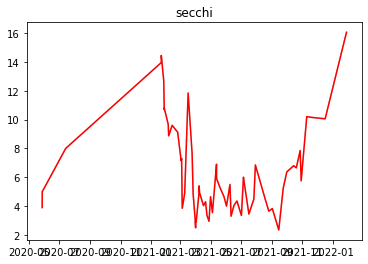

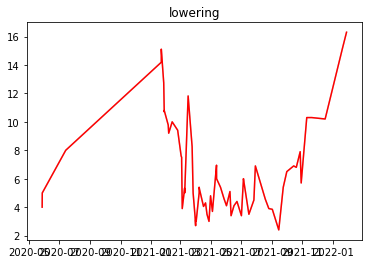

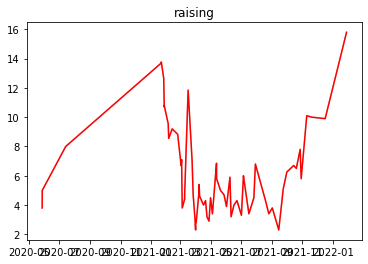

In [4]:
plot_data(df, qa_original.keys())

### Experiment With Checks 

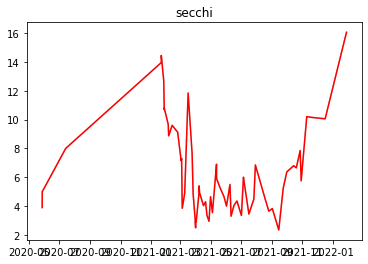

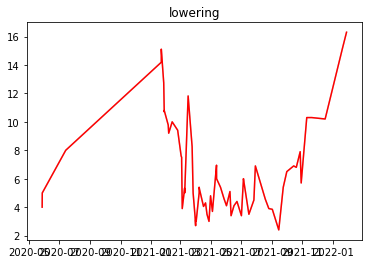

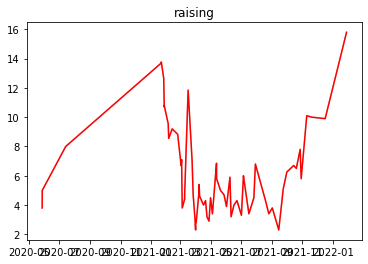

In [5]:
qa = copy.deepcopy(qa_original)
qa["secchi"]["simple"]["bounds"][0] = -1
qa["secchi"]["advanced"]["kmeans"] = {"ncluster":10}

df = quality_flags(qa, df)
plot_data(df, qa.keys())

### Write QA to File

In [ ]:
with open(qa_file, 'r+') as fp:
    json.dump(qa, fp)
update_log(qa, qa_original, "secchi") 

# Individual Check